# PCBVision - Dataset Exploration

## Objective

Before training any computer vision model, it is important to understand the dataset.

This notebook explores the PCB defect dataset by:

- inspecting the dataset structure
- loading metadata
- analyzing class distribution
- exploring image properties
- visualizing sample images
- identifying potential data quality issues

The findings from this notebook will guide preprocessing and model training decisions.

In [1]:
from pathlib import Path

import yaml
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from collections import Counter

In [2]:
DATASET_PATH = Path("../data/pcb-defect-dataset")
for path in sorted((DATASET_PATH / "train").iterdir()):
    print(path.name)

.DS_Store
images
labels


In [3]:
with open(DATASET_PATH / "data.yaml") as f:
    data_config = yaml.safe_load(f)

data_config

{'path': '../pcb-defect-dataset',
 'train': 'train',
 'val': 'val',
 'test': 'test',
 'names': {0: 'mouse_bite',
  1: 'spur',
  2: 'missing_hole',
  3: 'short',
  4: 'open_circuit',
  5: 'spurious_copper'}}

In [4]:
train_images = list((DATASET_PATH / "train/images").glob("*"))
valid_images = list((DATASET_PATH / "val/images").glob("*"))
test_images = list((DATASET_PATH / "test/images").glob("*"))

print(f"Train: {len(train_images)}")
print(f"Validation: {len(valid_images)}")
print(f"Test: {len(test_images)}")

Train: 8534
Validation: 1066
Test: 1068


Text(0.5, 1.0, 'rotation_270_light_12_short_08_4_600.jpg')

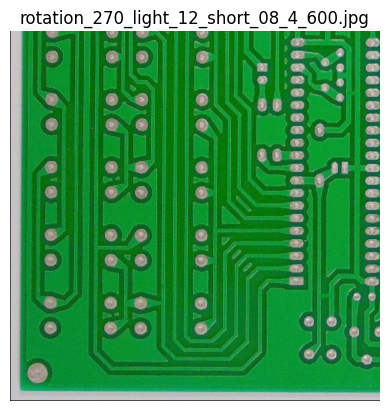

In [5]:

image_path = random.choice(train_images)

image = cv2.imread(str(image_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis("off")
plt.title(image_path.name)

In [6]:
sizes = []

for image_path in train_images:
    image = cv2.imread(str(image_path))
    h, w = image.shape[:2]
    sizes.append((w, h))

pd.DataFrame(sizes, columns=["width", "height"]).describe()

,width,height
count,8534.000000,8534.000000
mean,600.248067,600.248067
std,0.431916,0.431916
min,600.000000,600.000000
25%,600.000000,600.000000
50%,600.000000,600.000000
75%,600.000000,600.000000
max,601.000000,601.000000


In [7]:
label_files = list((DATASET_PATH / "train" / "labels").glob("*.txt"))

print(f"Number of label files: {len(label_files)}")

class_counts = Counter()

for label_file in label_files:
    with open(label_file) as f:
        for line in f:
            class_id = int(line.split()[0])
            class_counts[class_id] += 1

class_counts

Number of label files: 8534


Counter({0: 2980, 5: 2966, 1: 2919, 2: 2902, 4: 2844, 3: 2731})

In [8]:
class_names = data_config["names"]

df_classes = pd.DataFrame(
    {
        "Class": [class_names[i] for i in class_counts.keys()],
        "Annotations": class_counts.values(),
    }
)

df_classes

,Class,Annotations
0,missing_hole,2902
1,spur,2919
2,spurious_copper,2966
3,short,2731
4,open_circuit,2844
5,mouse_bite,2980


In [9]:
df_classes = df_classes.sort_values(
    by="Annotations",
    ascending=False,
)

df_classes

,Class,Annotations
5,mouse_bite,2980
2,spurious_copper,2966
1,spur,2919
0,missing_hole,2902
4,open_circuit,2844
3,short,2731


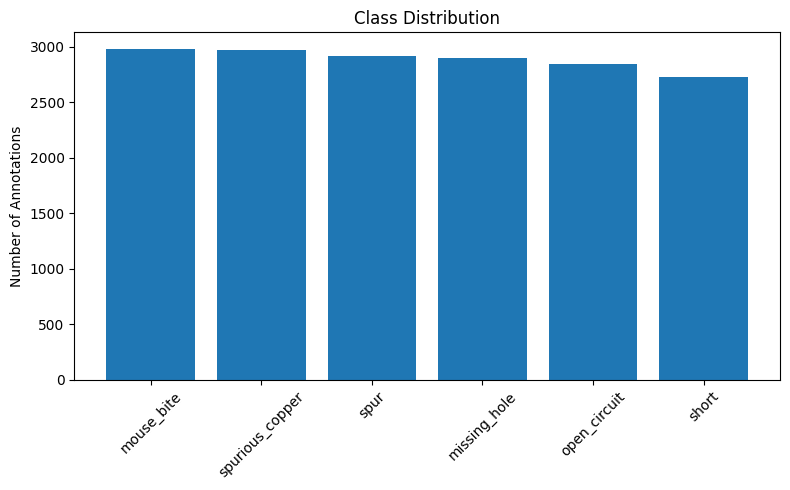

In [10]:
plt.figure(figsize=(8,5))

plt.bar(
    df_classes["Class"],
    df_classes["Annotations"],
)

plt.xticks(rotation=45)
plt.ylabel("Number of Annotations")
plt.title("Class Distribution")
plt.tight_layout()

In [11]:
objects_per_image = []

for label_file in label_files:
    with open(label_file) as f:
        objects_per_image.append(len(f.readlines()))

pd.Series(objects_per_image).describe()

count    8534.000000
mean        2.032107
std         1.016055
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         5.000000
dtype: float64

In [12]:
def load_yolo_annotations(label_path):
    boxes = []

    with open(label_path) as f:
        for line in f:
            values = line.strip().split()

            class_id = int(values[0])
            x_center = float(values[1])
            y_center = float(values[2])
            width = float(values[3])
            height = float(values[4])

            boxes.append(
                {
                    "class_id": class_id,
                    "x_center": x_center,
                    "y_center": y_center,
                    "width": width,
                    "height": height,
                }
            )

    return boxes

def yolo_to_bbox(box, image_width, image_height):

    x_center = box["x_center"] * image_width
    y_center = box["y_center"] * image_height

    width = box["width"] * image_width
    height = box["height"] * image_height

    x_min = int(x_center - width / 2)
    y_min = int(y_center - height / 2)

    x_max = int(x_center + width / 2)
    y_max = int(y_center + height / 2)

    return x_min, y_min, x_max, y_max

(np.float64(-0.5), np.float64(599.5), np.float64(599.5), np.float64(-0.5))

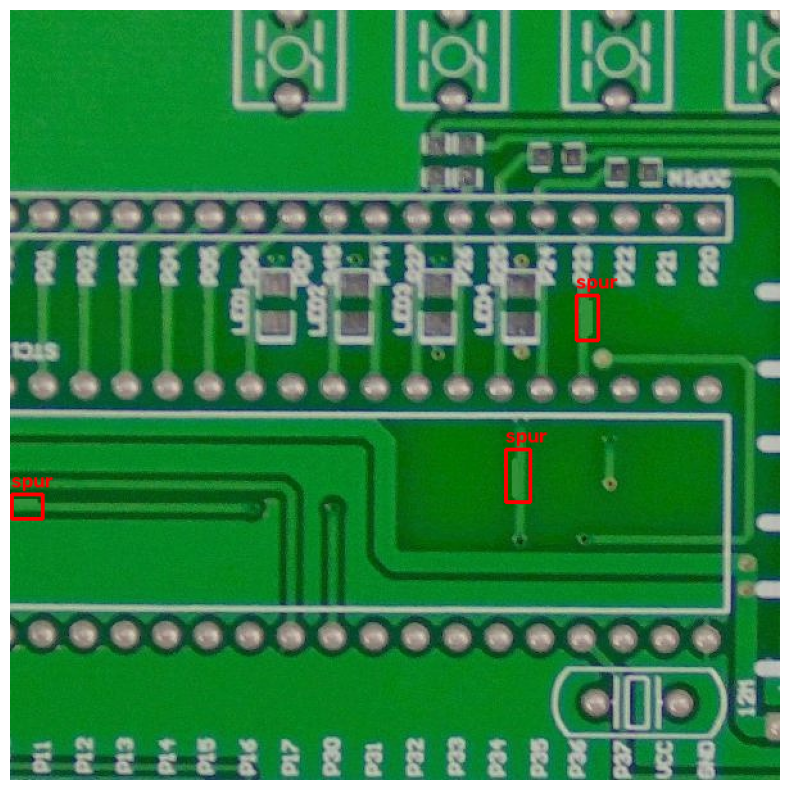

In [17]:
image_path = random.choice(train_images)

label_path = (
    DATASET_PATH
    / "train"
    / "labels"
    / f"{image_path.stem}.txt"
)

image = cv2.imread(str(image_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

height, width = image.shape[:2]

boxes = load_yolo_annotations(label_path)

for box in boxes:

    x1, y1, x2, y2 = yolo_to_bbox(box, width, height)

    class_name = class_names[box["class_id"]]

    cv2.rectangle(
        image,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),
        2,
    )

    cv2.putText(
        image,
        class_name,
        (x1, y1 - 5),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.5,
        (255, 0, 0),
        2,
    )

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis("off")

# Conclusions

The PCB defect dataset follows the standard YOLO dataset structure, consisting of separate training, validation, and test splits accompanied by a `data.yaml` configuration file. The dataset contains six defect classes:

- Mouse Bite
- Spur
- Missing Hole
- Short
- Open Circuit
- Spurious Copper

The dataset is composed of:

| Split | Images |
|-------|-------:|
| Training | 8,534 |
| Validation | 1,066 |
| Test | 1,068 |

Image dimensions are highly consistent, with almost all images measuring **600 × 600 pixels** (a few images are 601 × 601 pixels due to preprocessing or augmentation). This consistency simplifies the preprocessing pipeline since no additional resizing strategy needs to be considered during the exploration stage.

The annotation analysis shows a total of **17,342 annotated defects** across the training set. The six defect classes are relatively balanced, with each class containing approximately **2,700–3,000 instances**. This balanced distribution reduces the likelihood of severe class imbalance during model training.

The analysis of objects per image revealed that most images contain **one to three defects**, with an average of approximately **two defects per image**. The maximum number of annotated defects observed in a single image was **five**.

Finally, a visual inspection of randomly selected images confirmed that the bounding boxes are correctly aligned with the PCB defects and that the class labels appear consistent with the visual content. No obvious annotation errors or corrupted samples were identified during this initial inspection.

Overall, the dataset appears to be clean, well-organized, and suitable for training an object detection model. The next step will be to establish a baseline YOLO model and evaluate its performance on this dataset.